![HydroCycle](images/hydro_5cycle.jpg)

# Retrieve and Analyze Hydrology data for a watershed of interest

To make predictions for reservoir operations, water supply, flood control, etc, we need to collect data to train/calibrate hydrologic models. This includes streamflow, current environmental conditions (e.g., snow water equivalent), and future weather predictions. This exercise will build on the previous SNOTEL module to work towards building a hydrologic module.

Need to find a station? Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/)


Click the link and explore!

# 1. Delineated Watershed Map Upstream of a NWIS Site
The following code uses the pynhd and folium packages to create an interactive map of a watershed from a USGS gauge ID.

In our exercise, we are tasked with identifying all SNOTEL sites upstream of Hetch Hetchy Reservoir on the Tuolumne River. The user can search for "USGS streamflow Tuolumne River" and serveral locations will pop up. Site [11274790](https://waterdata.usgs.gov/monitoring-location/11274790/#dataTypeId=continuous-00065-0&period=P7D&showMedian=false) is the site of interest for this assessment 

In [1]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")


Define the watershed outlet using NWIS site id. Create a map object that we'll add layers to.

In [2]:
nldi = NLDI()
usgs_gage_id = "11274790" # NWIS id for Tuolumne river at the mouth of Hetch Hetchy Reservoir


## Get meterological information data for our area of interest using GEE and NLDAS2

We will be using the GEE python api to retrived NLDAS2 meteorological data from the [NLDAS Earth Engine Catalog](https://developers.google.com/earth-engine/datasets/catalog/NASA_NLDAS_FORA0125_H002).

![GEE_NLDAS](images/NASA_NLDAS_FORA0125_H002_sample.png)


In [ ]:
# Get geometry and ensure CRS is correct
basin = nldi.get_basins(usgs_gage_id) #get basin information, we could load the files that we saved too
geometry = basin.to_crs("EPSG:4326").geometry[0] # Get the bounding box of the geometry
basin_polygon_coords = list(geometry.exterior.coords)

In [4]:
#we can get hourly data  but it can take a long time and crash if the start and end date are too far apart
hourly_NLDAS_df = getData.get_NLDAS_hourly(basin_polygon_coords)
hourly_NLDAS_df.head()



Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2025-12-30T00:00:00,0,172.669593,0,0.121580,72526.931766,74.186356,0.001754,-1.542932,0.0,-3.768520,-0.331718
2025-12-30T01:00:00,0,172.661561,0,0.015232,72528.440877,0.000000,0.001446,-2.025731,0.0,-3.886196,-0.412349
2025-12-30T02:00:00,0,172.647718,0,0.015232,72529.957224,0.000000,0.001137,-2.507450,0.0,-4.004585,-0.493898
2025-12-30T03:00:00,0,173.021182,0,0.015232,72531.429234,0.000000,0.000829,-2.990934,0.0,-4.119638,-0.571880
2025-12-30T04:00:00,0,173.022314,0,0.015069,72517.665395,0.000000,0.000801,-2.885945,0.0,-4.053641,-0.270350


In [ ]:
#It crashes if we try to get too much data at once, so we will get daily data for a smaller range of dates
Daily_NLDAS_df1 = getData.get_NLDAS_daily(basin_polygon_coords, begin_date='2006-01-01', end_date='2012-01-1')
Daily_NLDAS_df1.head()

Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2006-01-01,0.005192,199.833836,1.508087,0.044990,71408.170160,95.234192,0.002439,-7.561317,0.563703,2.807882,5.710911
2006-01-02,0.051767,264.132482,33.055034,0.013663,70799.285724,93.932771,0.004772,-0.944478,4.532128,4.467674,8.864378
2006-01-03,0.016707,214.292827,9.209950,0.030093,71724.799553,101.167170,0.002966,-6.371842,0.575387,4.247262,3.778855
2006-01-04,0.000000,226.581243,0.000000,0.016272,72808.304958,101.368610,0.003240,-3.462835,0.002358,1.485389,1.450410
2006-01-05,0.000000,214.910143,0.000000,0.033974,73429.441947,112.546583,0.002849,1.320337,0.000000,-0.779809,3.417216


In [7]:
#It crashes if we try to get too much data at once, so we will get daily data for a smaller range of dates
Daily_NLDAS_df_2 = getData.get_NLDAS_daily(basin_polygon_coords, begin_date='2012-01-1', end_date='2018-01-1')
Daily_NLDAS_df_2.head()

Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2012-01-01,0.0,189.961892,0.0,0.020069,72932.843593,115.136221,0.002084,-0.202470,0.0,-0.991600,2.050845
2012-01-02,0.0,182.659036,0.0,0.074016,72938.497667,114.566230,0.001812,-0.135426,0.0,0.471567,4.762250
2012-01-03,0.0,186.784356,0.0,0.057585,73102.016670,115.180582,0.001867,-0.252943,0.0,0.908515,3.012314
2012-01-04,0.0,203.650393,0.0,0.016956,73281.697993,114.207124,0.002370,1.254940,0.0,0.281917,2.012439
2012-01-05,0.0,199.040962,0.0,0.019039,73114.227991,115.751271,0.002468,0.890008,0.0,0.547861,0.219101


In [8]:
#It crashes if we try to get too much data at once, so we will get daily data for a smaller range of dates
Daily_NLDAS_df_3 = getData.get_NLDAS_daily(basin_polygon_coords, begin_date='2018-01-1', end_date='2022-01-1')
Daily_NLDAS_df_3.head()

Authenticating with Earth Engine...
Initializing Earth Engine...
Earth Engine initialized successfully.


,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2018-01-01,0.000000,213.800975,0.000000,0.043056,72743.806196,108.580816,0.002056,0.237548,0.000000,0.364702,1.898353
2018-01-02,0.000000,204.065878,0.000000,0.014744,72883.815261,108.682097,0.002514,0.174304,0.000000,-1.076387,1.537924
2018-01-03,0.000000,223.960795,0.000000,0.043999,72643.889605,104.670993,0.002524,0.519115,0.000000,-0.218272,3.318727
2018-01-04,0.000000,260.845301,0.000000,0.016014,72416.805059,100.806345,0.004571,0.430183,0.081611,0.572277,4.713699
2018-01-05,0.000321,219.271025,0.038969,0.023548,72473.213601,97.696687,0.003904,-1.310952,0.012962,1.340124,4.438616


In [ ]:
#combine the three dataframes into one
Daily_NLDAS_df = pd.concat([Daily_NLDAS_df1, Daily_NLDAS_df_2, Daily_NLDAS_df_3], ignore_index=False)
#set 
Daily_NLDAS_df.head()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2006-01-01,0.005192,199.833836,1.508087,0.044990,71408.170160,95.234192,0.002439,-7.561317,0.563703,2.807882,5.710911
2006-01-02,0.051767,264.132482,33.055034,0.013663,70799.285724,93.932771,0.004772,-0.944478,4.532128,4.467674,8.864378
2006-01-03,0.016707,214.292827,9.209950,0.030093,71724.799553,101.167170,0.002966,-6.371842,0.575387,4.247262,3.778855
2006-01-04,0.000000,226.581243,0.000000,0.016272,72808.304958,101.368610,0.003240,-3.462835,0.002358,1.485389,1.450410
2006-01-05,0.000000,214.910143,0.000000,0.033974,73429.441947,112.546583,0.002849,1.320337,0.000000,-0.779809,3.417216


In [15]:
Daily_NLDAS_df.tail()

,convective_fraction,longwave_radiation,potential_energy,potential_evaporation,pressure,shortwave_radiation,specific_humidity,temperature,total_precipitation,wind_u,wind_v
Date,,,,,,,,,,,
2021-12-27,0.018223,219.984779,7.729698,0.026481,71003.241333,65.660055,0.001950,-11.505627,0.725131,6.359012,6.717583
2021-12-28,0.002725,214.808744,0.018763,0.019029,70766.391160,66.984720,0.001898,-11.786303,0.046239,4.240648,2.041985
2021-12-29,0.000412,205.754843,1.239420,0.013572,70737.086034,67.270818,0.001965,-11.617362,0.190203,1.939715,4.258089
2021-12-30,0.000000,178.973635,0.246624,0.012914,71102.204130,111.694618,0.002160,-9.993520,0.067344,1.640725,3.325037
2021-12-31,0.000000,178.731055,0.000000,0.032721,71057.141310,112.494972,0.002094,-8.306853,0.000092,5.121601,1.422705


## Data exploration

### Lets examine basin longwave and shortwave radiation

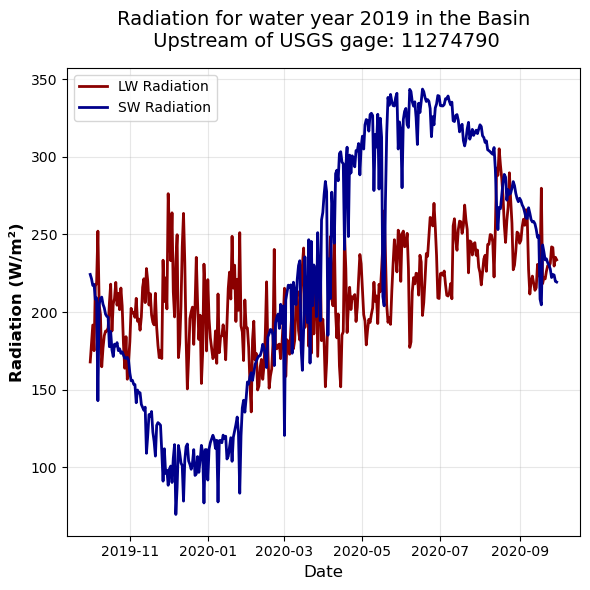

In [16]:
#For year 2019, plot all SWE_cm columns
met_df_2019 = Daily_NLDAS_df.loc['2019-10-01':'2020-09-30'].copy()
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Radiation (W/m²)', color='black', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['longwave_radiation'], linewidth=2, label = 'LW Radiation', color='darkred')
ax1.plot(met_df_2019.index, met_df_2019['shortwave_radiation'], linewidth=2, label = 'SW Radiation', color='darkblue')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f" Radiation for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Lets look at temperature

In [17]:
met_df_2019.columns

Index(['convective_fraction', 'longwave_radiation', 'potential_energy',
       'potential_evaporation', 'pressure', 'shortwave_radiation',
       'specific_humidity', 'temperature', 'total_precipitation', 'wind_u',
       'wind_v'],
      dtype='object')

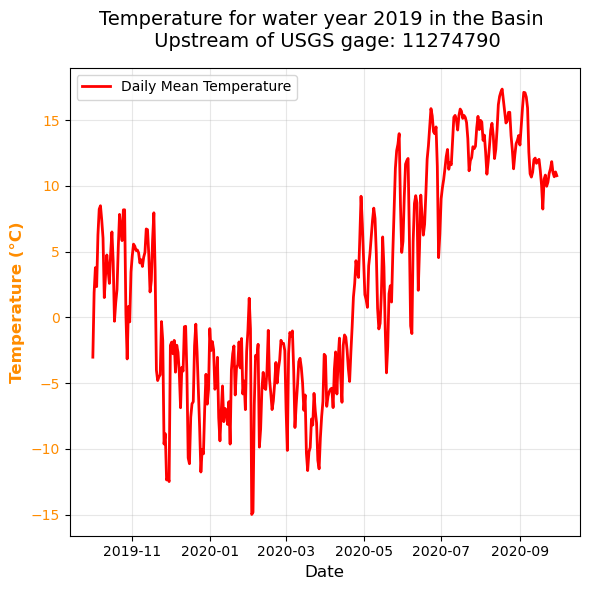

In [18]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='darkorange', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['temperature'], linewidth=2, label = 'Daily Mean Temperature', color='red')
ax1.tick_params(axis='y', labelcolor='darkorange')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f"Temperature for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Precipitation and temperature

Use a dual y-axies to plot both on the same plot. 

What insights can we make about the type of precipitation?

In [19]:
def align_yaxis(ax1, ax2):
    """Align zeros of the two axes by adjusting their limits."""
    # Get current limits
    y1_min, y1_max = ax1.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    # Calculate the ratio of the zero point relative to the total range
    # Example: If zero is exactly in the middle, ratio = 0.5
    y1_ratio = -y1_min / (y1_max - y1_min)
    y2_ratio = -y2_min / (y2_max - y2_min)

    # Adjust the axis with the smaller ratio to match the larger one
    if y1_ratio < y2_ratio:
        ax1.set_ylim(bottom=-y1_max * y2_ratio / (1 - y2_ratio))
    else:
        ax2.set_ylim(bottom=-y2_max * y1_ratio / (1 - y1_ratio))

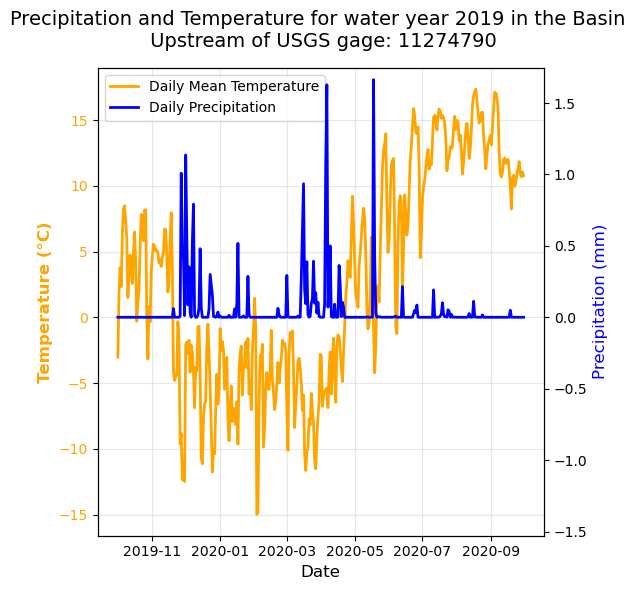

In [20]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', color='orange', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['temperature'], linewidth=2, label = 'Daily Mean Temperature', color='orange')
#ax1.plot(met_df_2019.index, met_df_2019['prcp_mm_day'], linewidth=2, label = 'Daily Precipitation', color='blue')
ax1.tick_params(axis='y', labelcolor='orange')
#make secondary y-axis for precipitation
ax2 = ax1.twinx()
ax2.plot(met_df_2019.index, met_df_2019['total_precipitation'], linewidth=2, label = 'Daily Precipitation', color='blue')
ax2.set_ylabel('Precipitation (mm)', color='blue', fontsize=12)
ax1.grid(True, alpha=0.3)
align_yaxis(ax1, ax2)

#Ask both axes for their handles and labels
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

#Combine them and create one legend
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')


# Title and Layout
plt.title(f"Precipitation and Temperature for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### Plot wind

wind_u (Zonal Wind): Represents the east-west component. A positive value indicates wind blowing toward the east (from the west).

wind_v (Meridional Wind): Represents the north-south component. A positive value indicates wind blowing toward the north (from the south)

In [76]:
met_df_2019.columns


Index(['convective_fraction', 'longwave_radiation', 'potential_energy',
       'potential_evaporation', 'pressure', 'shortwave_radiation',
       'specific_humidity', 'temperature', 'total_precipitation', 'wind_u',
       'wind_v'],
      dtype='object')

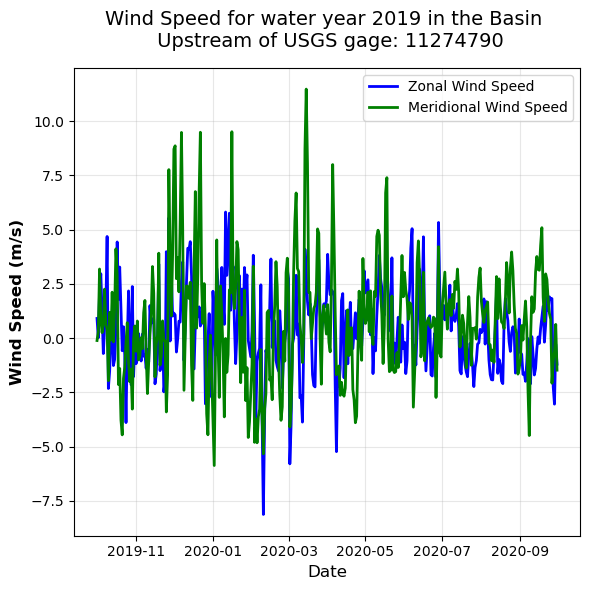

In [77]:
#make the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# --- Primary Y-axis: SWE_cm ---
ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Wind Speed (m/s)', color='black', fontsize=12, fontweight='bold')
ax1.plot(met_df_2019.index, met_df_2019['wind_u'], linewidth=2, label = 'Zonal Wind Speed', color='blue')
ax1.plot(met_df_2019.index, met_df_2019['wind_v'], linewidth=2, label = 'Meridional Wind Speed', color='green')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3)

#show a legend
ax1.legend()

# Title and Layout
plt.title(f"Wind Speed for water year 2019 in the Basin \n Upstream of USGS gage: {usgs_gage_id}", fontsize=14, pad=15)
fig.tight_layout()
plt.show()

### save the data for future use!

In [21]:
#save the cleaned dataframe to a csv file
# Use the getData module to retrieve data 
OutputFolder = 'files/NLDAS'
if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)
Daily_NLDAS_df.to_csv(f'{OutputFolder}/NLDAS_{usgs_gage_id}.csv')

## Exercise: Fetch a variable of your choice from Earth Engine

In this exercise, you are tasked with getting another variable from the [Google Earth Engine data catelog](https://developers.google.com/earth-engine/datasets/), something like the [MODIS Snow Covered Daily product](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD10A1). Add your function to your getData.py script and create a data processing function to bring to a daily resolution (if necessary) into dataprocessing.py. Plot you data either as a time series (as we have previously done) or over the basin for a single day.